In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/diabetes.csv")

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
x=df.iloc[:,0:8]
y=df.iloc[:,-1]

In [ ]:
x.shape

(768, 8)

In [ ]:
y.shape

(768,)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [ ]:
x_train.shape

(614, 8)

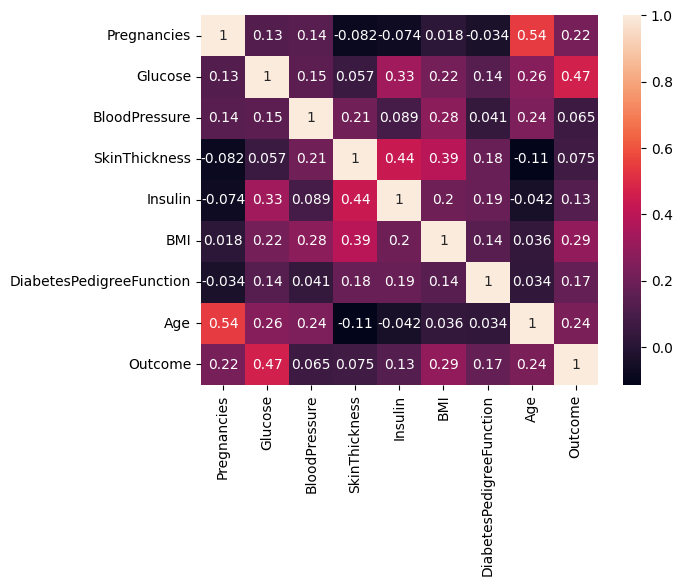

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

<Axes: xlabel='Outcome', ylabel='Glucose'>

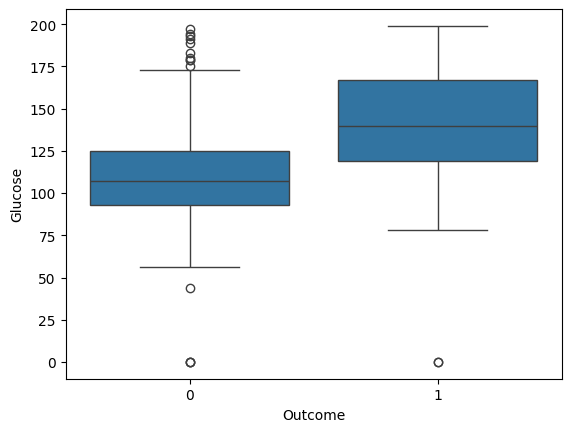

In [ ]:
sns.boxplot(y="Glucose",x="Outcome",data=df)

<Axes: xlabel='Outcome', ylabel='Age'>

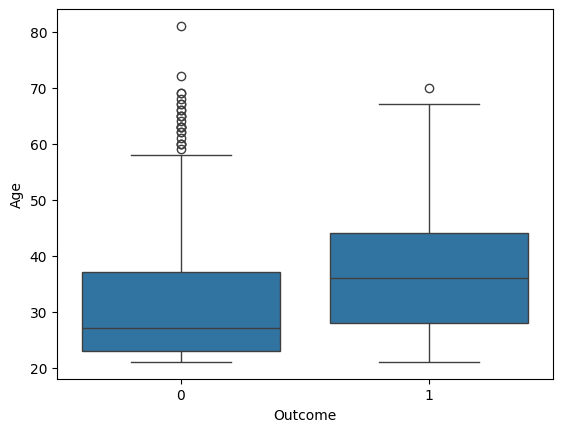

In [ ]:
sns.boxplot(x="Outcome",y="Age",data=df)

<Axes: xlabel='Outcome', ylabel='count'>

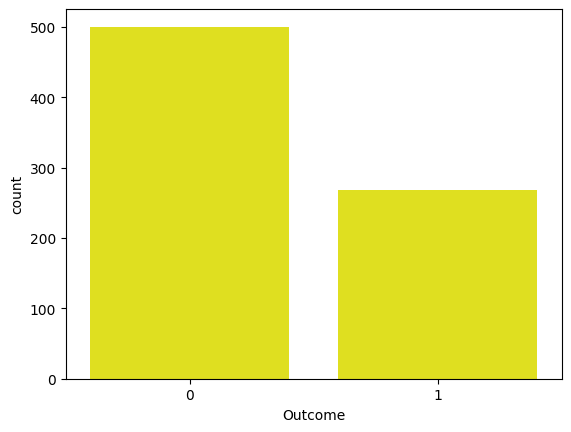

In [ ]:
sns.countplot(data=df,x="Outcome",color="yellow")

<Axes: xlabel='Outcome', ylabel='BMI'>

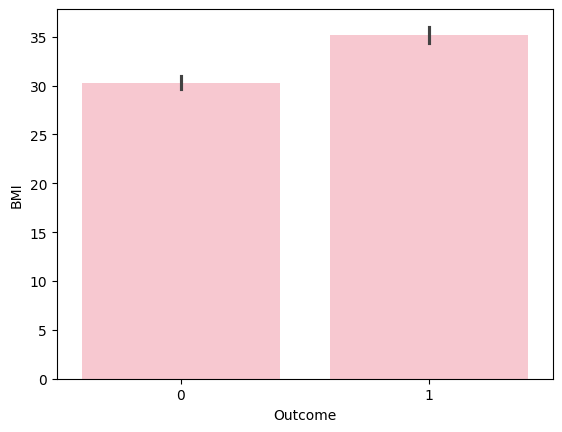

In [ ]:
sns.barplot(y="BMI",x="Outcome",data=df,color="pink")

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
log=LogisticRegression()
log.fit(x_train,y_train)

LogisticRegression()

In [ ]:
y_pred=log.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix



In [ ]:
from sklearn.metrics import precision_score,recall_score,f1_score
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))

Accuracy: 0.7792207792207793
Precision: 0.7560975609756098
Recall: 0.5636363636363636
F1 Score: 0.6458333333333334


In [ ]:
pd.DataFrame(confusion_matrix(y_test,y_pred))


,0,1
0,89,10
1,24,31


Text(50.722222222222214, 0.5, 'Actual')

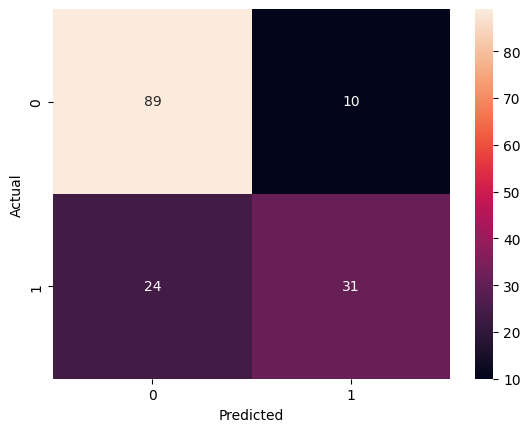

In [ ]:
map=confusion_matrix(y_test,y_pred)
sns.heatmap(map,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [ ]:
epo=np.array([[6	,148,	72,	35,	0	,33.6,	0.627,	50]])
sc.transform(epo)

log.predict(epo)

array([1])

In [ ]:
epo=np.array([[3,120,66,30,0,26,.325,30]])
print(log.predict(epo))

[1]


In [ ]:
print(log.coef_)
print(log.intercept_)

[[ 0.42377182  1.13266335 -0.28485107 -0.034683   -0.09455439  0.65076822
   0.22909913  0.1355653 ]]
[-0.88027923]


In [ ]:
df_coef=pd.DataFrame({
    "features":x.columns,
    "coef_":log.coef_[0]
})
print(df_coef)

                   features     coef_
0               Pregnancies  0.423772
1                   Glucose  1.132663
2             BloodPressure -0.284851
3             SkinThickness -0.034683
4                   Insulin -0.094554
5                       BMI  0.650768
6  DiabetesPedigreeFunction  0.229099
7                       Age  0.135565


In [ ]:
df_coef=df_coef.sort_values(
    by="coef_",
    ascending=False
)
print(df_coef)

                   features     coef_
1                   Glucose  1.132663
5                       BMI  0.650768
0               Pregnancies  0.423772
6  DiabetesPedigreeFunction  0.229099
7                       Age  0.135565
3             SkinThickness -0.034683
4                   Insulin -0.094554
2             BloodPressure -0.284851


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Glucose'),
  Text(1, 0, 'BMI'),
  Text(2, 0, 'Pregnancies'),
  Text(3, 0, 'DiabetesPedigreeFunction'),
  Text(4, 0, 'Age'),
  Text(5, 0, 'SkinThickness'),
  Text(6, 0, 'Insulin'),
  Text(7, 0, 'BloodPressure')])

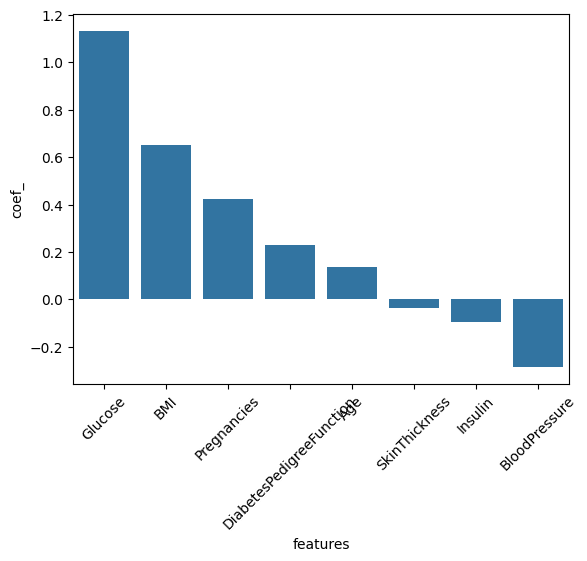

In [ ]:
sns.barplot(x="features",y="coef_",data=df_coef)
plt.xticks(rotation=45)